(WillmoreClosed)=
# Willmore flow for closed surfaces

Given a closed surface $\Gamma$, its Willmore flow is described as the flow minimizing the functional
\begin{equation*}
\mathcal{E}(\Gamma) = \int_\Gamma (H-H_0)^2 \mathrm{d}s
\end{equation*}

where $H$ is the mean curvature and $H_0$ is the spontaneous curvature.

It's significance is related to the elastic flow of cellular membrane as explained in the seminal work of Canham and Helfrich, but it also has imporant implications in the study of manifolds. It can be expressed as follows
\begin{equation*}
 \frac{\mathrm{d}\Gamma(t)}{\mathrm{d}t} = - \frac{\partial\mathcal{E}'(\Gamma)}{\partial\Gamma} = -\int_\Gamma (\Delta H -\frac{1}{2}(H-H_0)^2+(H-H_0)|\nabla\vec{\nu}|^2)w \mathrm{d}s
\end{equation*}

where $H$ is the surface mean curvature and $w$ is the **normal** velocity of the surface. To solve for the gradient flow using Finite Elements, what is usually done is to solve the PDE
\begin{equation*}
\frac{\mathrm{d}\vec{x}}{\mathrm{d}t} = -\Delta H +\frac{1}{2}(H-H_0)^2-(H-H_0)|\nabla\vec{\nu}|^2
\end{equation*}

where $\vec{\nu}$ is the normal to the surface.

A peculiary of hyperspheres is that they are stable under Willmore flow. We will test that in the following for the circle and the sphere plotting the error with respect to exact solutions

WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.2…

WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.2…

     Time  displacement  mean_curv
0    0.00      0.000000   0.002146
1    0.01      0.000032   0.002170
2    0.02      0.000032   0.002139
3    0.03      0.000032   0.002107
4    0.04      0.000033   0.002075
..    ...           ...        ...
196  1.96      0.000219   0.016496
197  1.97      0.000221   0.016716
198  1.98      0.000223   0.016938
199  1.99      0.000226   0.017162
200  2.00      0.000228   0.017388

[201 rows x 3 columns]


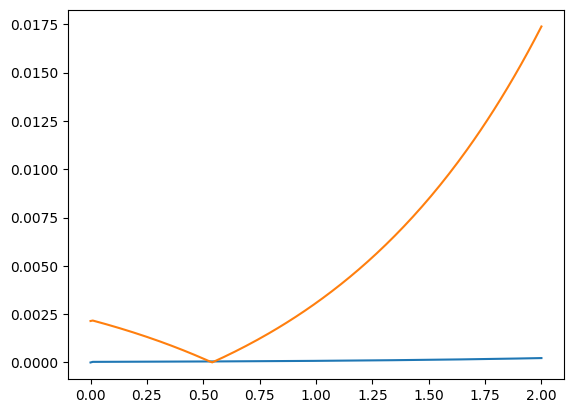

In [1]:
# %%

from cosmos.solvers.willmore import StabWillmoreSolver
from cosmos.solvers.simulation import MovingSimulation
from cosmos.utils.generate_surface_meshes import generate_circle
from ngsolve import *
import numpy as np
from ngsolve.webgui import Draw
import matplotlib.pyplot as plt
import pandas as pd


mesh, _ = generate_circle(R=1)

n_ex = CF((x,y))/Norm(CF((x,y)))

'''
Definition of the time parameters
'''
T = 2
dt = Parameter(0.01)
t = Parameter(0)

'''
Definition of the simulation
'''
simulation = MovingSimulation(mesh=mesh, dt=dt, t=t, T=T)

displ_solver = StabWillmoreSolver(sp_curv = -1)

simulation.AddMotionSolver(displ_solver)

def displ():
    return displ_solver.get_solution()[0]

simulation.AddMotion(function=displ, domain = '.*')

displ_solver.SaveSolution(folderpath = './willmore_results/', filename = 'circle', n_steps = 10)
displ_solver.ComputeError(folderpath = './willmore_results/', filename = 'circle_errs', ex_sol = [CF((0,0)), -n_ex], norm = 'L2')


simulation.run()

displ_solver.draw_solution()


file_path = "./willmore_results/circle_errs"

# Read the CSV into a DataFrame
df = pd.read_csv(file_path)

print(df)

plt.plot(df['Time'], df['displacement'])
plt.plot(df['Time'], df['mean_curv'])
plt.show()


And the case of the sphere follows

WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.2…

WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.2…

    Time  displacement  mean_curv
0   0.00      0.000000   0.215148
1   0.01      0.001117   0.028238
2   0.02      0.001130   0.013992
3   0.03      0.001084   0.012293
4   0.04      0.001043   0.011027
5   0.05      0.001006   0.010103
6   0.06      0.000970   0.009570
7   0.07      0.000936   0.009445
8   0.08      0.000903   0.009701
9   0.09      0.000872   0.010272
10  0.10      0.000842   0.011077


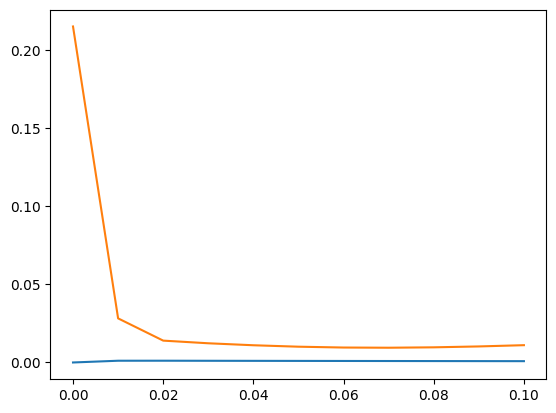

In [2]:
from cosmos.utils.generate_surface_meshes import generate_sphere

mesh, _ = generate_sphere(R=1)

n_ex = CF((x,y,z))/Norm(CF((x,y,z)))

'''
Definition of the time parameters
'''
T = 0.1
dt = Parameter(0.01)
t = Parameter(0)

'''
Definition of the simulation
'''
simulation = MovingSimulation(mesh=mesh, dt=dt, t=t, T=T)

displ_solver = StabWillmoreSolver(sp_curv = -2)

simulation.AddMotionSolver(displ_solver)

def displ():
    return displ_solver.get_solution()[0]

simulation.AddMotion(function=displ, domain = '.*')

displ_solver.SaveSolution(folderpath = './willmore_results/', filename = 'sphere', n_steps = 10)
displ_solver.ComputeError(folderpath = './willmore_results/', filename = 'sphere_errs', ex_sol = [CF((0,0, 0)), -2*n_ex], norm = 'L2')


simulation.run()

displ_solver.draw_solution()


file_path = "./willmore_results/sphere_errs"

# Read the CSV into a DataFrame
df = pd.read_csv(file_path)

print(df)

plt.plot(df['Time'], df['displacement'])
plt.plot(df['Time'], df['mean_curv'])
plt.show()


We now try to simulate the Willmore flow of a square. As shown above, we should restore the shape of a circle as the optimal solution.

In [3]:
mesh = Mesh(unit_square.GenerateMesh(maxh = 0.05))

n_ex = CF((x,y))/Norm(CF((x,y)))

'''
Definition of the time parameters
'''
T = 1
dt = Parameter(0.01)
t = Parameter(0)

'''
Definition of the simulation
'''
simulation = MovingSimulation(mesh=mesh, dt=dt, t=t, T=T)

displ_solver = StabWillmoreSolver()

simulation.AddMotionSolver(displ_solver)

def displ():
    return displ_solver.get_solution()[0]

simulation.AddMotion(function=displ, domain = '.*')

displ_solver.SaveSolution(folderpath = './willmore_results/', filename = 'square', n_steps = 10)


simulation.run()

displ_solver.draw_solution()


WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.2…

WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.2…